In [2]:
#%% Create Map for figure 1 
import os, sys
# exec(open(os.environ['PYTHONSTARTUP']).read())
STARTUP_2026_coldfronts_mhws = "./2026_coldfronts_mhws_startup.py"
exec(open(STARTUP_2026_coldfronts_mhws).read())



proj_lamb = ccrs.LambertConformal(
    central_longitude=-65,
    central_latitude=45,
    standard_parallels=(35, 55),
)


In [3]:
from dask.distributed import Client, LocalCluster

client = Client(n_workers=24, threads_per_worker=4,processes=True,ip="0.0.0.0",memory_limit='1GB')  # Adjust memory limit as needed
# display cluster information in dash board
display(client)  # if print(display) link to dashboard not correct

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://10.128.43.2:8787/status,
Dashboard: http://10.128.43.2:8787/status,Workers: 24
Total threads: 96,Total memory: 22.35 GiB
Status: running,Using processes: True
Comm: tcp://10.128.43.2:40079,Workers: 24
Dashboard: http://10.128.43.2:8787/status,Total threads: 96
Started: Just now,Total memory: 22.35 GiB
Comm: tcp://10.128.43.2:39563,Total threads: 4
Dashboard: http://10.128.43.2:34829/status,Memory: 0.93 GiB
Nanny: tcp://10.128.43.2:39829,


In [ ]:
# client.close()

# MHW frequency

MHW detection performed with https://github.com/coecms/xmhw

In [4]:
interm = xr.open_dataset('/srv/data/MarineHeatwaves/intermediate_oisst_base_1983_2012_80W_65W_35N_46N_encoded.nc') # daily data
# percentage of MHW days between 2010 and 2022
dummy =  interm['mask'].sel(time=slice('2010','2022')) # mask is binary with 1 when MHW, just sum up
MHW_days = dummy.sum('time')/len(dummy.time)*100 # in percentage

# dave to file
MHW_days.to_netcdf('../data/MHW_days_2010_2022.nc')
del dummy

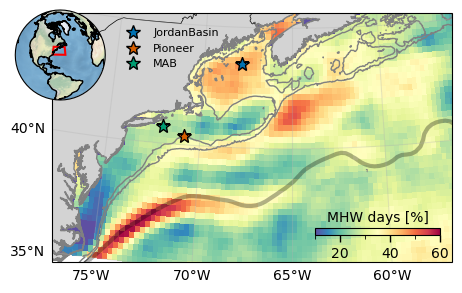

In [5]:
font_for_pres()
fig,ax = plt.subplots(figsize=(5,3),subplot_kw={'projection': proj_lamb})
plot_map_NWA(ax,[-77,-57,35,45],c=[100,1000],plotbathy='contour',gulfstream=True)
cc=MHW_days.plot(ax=ax,cmap='Spectral_r',vmin=10,vmax=60,add_colorbar=False,
            transform=ccrs.PlateCarree())
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# Horizontal inset colorbar
cax = fig.add_axes([0.66, 0.21, 0.25, 0.025])
cb = plt.colorbar(
    cc,
    cax=cax,
    orientation="horizontal",
    ticks=[20,40,60]
)
cb.set_label("MHW days [%]")
cb.ax.xaxis.set_label_position("top")
cb.ax.xaxis.set_minor_locator(MultipleLocator(10))
cb.ax.tick_params(which="minor", length=3)
cb.ax.tick_params(which="major", length=5)


# locations
lat = [43.49,40.362,40.693]
lon = [-67.88,-70.8785,-72.049]
for i,j,c,l in zip(lon,lat,['#0072B2','#D55E00','#009E73'],['JordanBasin','Pioneer','MAB']):
    ax.plot(i,j,marker='*',markersize=10,markerfacecolor=c,markeredgecolor='k',
            transform=ccrs.PlateCarree(),linestyle='None',label=l)
ax.legend(fontsize=8,loc="upper left", bbox_to_anchor=(0.15, 0.98))


# inset for globe
axins = fig.add_axes(
    [0, 0.66, 0.3, 0.3],
    projection=ccrs.Orthographic(
        central_longitude=-65,
        central_latitude=35,
    ),
)
axins.stock_img()
axins.coastlines()
# Target region rectangle
lon0, lon1, lat0, lat1 = [-77,-57,35,45]
rect = Rectangle(
    (lon0, lat0),
    lon1 - lon0,
    lat1 - lat0,
    fill=False,
    edgecolor="red",
    linewidth=1.5,
    transform=ccrs.PlateCarree(),
)
axins.add_patch(rect)
plt.show()
 
# finished_plot(fig,'../plots/fig1a_MHW.jpg')

# Frontal frequency

In [ ]:
# -------------------------------------------------
# takes about 2min to run

# def preprocess(ds):
#     return ds[["F_type"]].sel(
#         lon=slice(260, 330),
#         lat=slice(60, 20),
#     )

# # F diagnostic calculated by co-author Rhys Parfitt
# front = xr.open_mfdataset(
#     "/vast/clidex/data/reanalysis/ERA/ERA5/subsets/atmos_eoas/F_diagnostic/front_types/F_comb_*.nc",
#     combine="by_coords",
#     preprocess=preprocess,
#     parallel=True,
#     chunks={"lon": 50, "lat": 50, "time": 124},
# )

# # boolean for different fronts
# is_cold = front["F_type"] == 1
# is_warm = front["F_type"] == -1
# is_all = is_cold | is_warm

# front_bool = xr.Dataset(
#     {
#         "cold": is_cold,
#         "warm": is_warm,
#         "all": is_all,
#     }
# )
# seasonal_freq = front_bool.groupby("time.season").mean("time") # mean works with boolean arrays, giving the fraction of time each condition is met
# annual_freq = front_bool.mean("time")

# front_freq = xr.merge(
#     [
#         seasonal_freq.rename({
#             "cold": "cold_seasonal",
#             "warm": "warm_seasonal",
#             "all": "all_seasonal",
#         }),
#         annual_freq.rename({
#             "cold": "cold_annual",
#             "warm": "warm_annual",
#             "all": "all_annual",
#         }),
#     ]
# )

# front_freq = front_freq.compute()
# front_freq.to_netcdf('../data/frontal_freq_fig1.nc')


front_freq = xr.open_dataset('../data/frontal_freq_fig1.nc')

python: /croot/libnetcdf_1691154366938/work/libsrc4/nc4internal.c:360: nc4_find_nc_grp_h5: Assertion `my_h5 && my_h5->root_grp' failed.
2026-09-25 12:59:39,769 - distributed.nanny - WARNING - Restarting worker


Exception ignored in: <function CachingFileManager.__del__ at 0x7f6717f69ee0>
Traceback (most recent call last):
  File "/home/sryan/.conda/envs/sirates/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 250, in __del__
    self.close(needs_lock=False)
  File "/home/sryan/.conda/envs/sirates/lib/python3.12/site-packages/xarray/backends/file_manager.py", line 234, in close
    file.close()
  File "src/netCDF4/_netCDF4.pyx", line 2624, in netCDF4._netCDF4.Dataset.close
  File "src/netCDF4/_netCDF4.pyx", line 2587, in netCDF4._netCDF4.Dataset._close
  File "src/netCDF4/_netCDF4.pyx", line 2028, in netCDF4._netCDF4._ensure_nc_success
RuntimeError: NetCDF: Not a valid ID


Saving ../plots/fig1b_fronts_annual.jpg


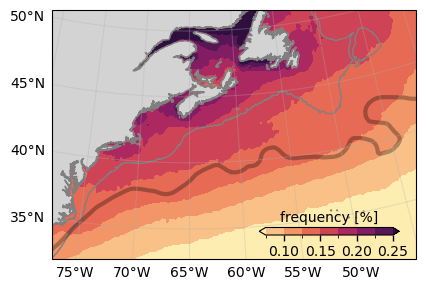

In [38]:
font_for_pres()
import cmocean as cmo
fig,ax = plt.subplots(figsize=(5,3),subplot_kw={'projection': proj_lamb})
plot_map_NWA(ax,[-77,-45,32,50],c=[1000],plotbathy='contour',gulfstream=True)
cc = front_freq['all_annual'].T.plot.contourf(levels=np.arange(0.075,0.275,0.025),cmap='cmo.matter',vmax=0.2,
                              add_colorbar=False,transform=ccrs.PlateCarree())
ax.set_title('')

# Horizontal inset colorbar
cax = fig.add_axes([0.55, 0.2, 0.28, 0.025])
cb = plt.colorbar(
    cc,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(0.1,0.3,0.05),
)
cb.set_label("frequency [%]")
cb.ax.xaxis.set_label_position("top")
finished_plot(fig,'../plots/fig1b_fronts_annual.jpg')